# Submission Notebook for 2026 Machine Learning Kaggle Competition
**Authors:** Zach Loo, Nathalie Bonnet, Leela Dixit, Jay Kim

**Date:** 06/11/2026

# Background
This notebook contains the code written to predict dissolved organic carbon (DIC) for California coastal waters. The data used to train regression models come from the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program, which monitors oceanographic conditions over time. The data contains DIC data from samples, and predictor features for sea water temperature, alkalinity, practical saliity, and sample depth. The goals of this notebook were to:
1. Explore sample data that can inform modeling decisions
2. Fit models to minimize tets MSE (obtain the best fitting model than can be generalized for other data)
3. Compare model results, comment on performance, and select an optimal model. 

**Citation and Acknowledgements:** Data are provided by the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program (https://calcofi.org). CalCOFI is a partnership among the NOAA Fisheries Service, the Scripps Institution of Oceanography, and the California Department of Fish and Wildlife.

# Setup

In [ ]:
# Install this package if needed
# pip install lightgbm --quiet
# pip install optuna

# Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os # since nathalie is windows user tehe
import optuna
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.decomposition import PCA
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [2]:
# Load training and test data
train = pd.read_csv(os.path.join("data", "train.csv"))
test = pd.read_csv(os.path.join("data", "test.csv"))

# Load submission example
submission = pd.read_csv(os.path.join("data", "sample_submission.csv"))

In [3]:
# Create names list of features
features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]

In [4]:
# Explore data
train.info()

# Create summary statistics table 
stats = train[features].agg(['mean', 'median', 'min', 'max', 'std'])
print(stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3389 entries, 0 to 3388
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3389 non-null   int64  
 1   CTDTEMP_ITS90   3389 non-null   float64
 2   Salinity_PSS78  3389 non-null   float64
 3   Depth           3389 non-null   float64
 4   TA              3389 non-null   float64
 5   DIC             3389 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 159.0 KB
        CTDTEMP_ITS90           TA  Salinity_PSS78        Depth
mean        11.819258  2251.047300       33.701898   144.232546
median      11.230000  2241.000000       33.609500    50.000000
min          1.520000  2163.800000       32.700000     0.000000
max         22.750000  2462.300000       34.680000  3542.000000
std          3.905980    32.675546        0.375517   262.640488


From a couple preliminary explorations, all data is non-null, so no need for any scrubbing! However, the scale of the features does not match at all, which can result in models unfairly penalizing larger features. So, we should scale the feature data.

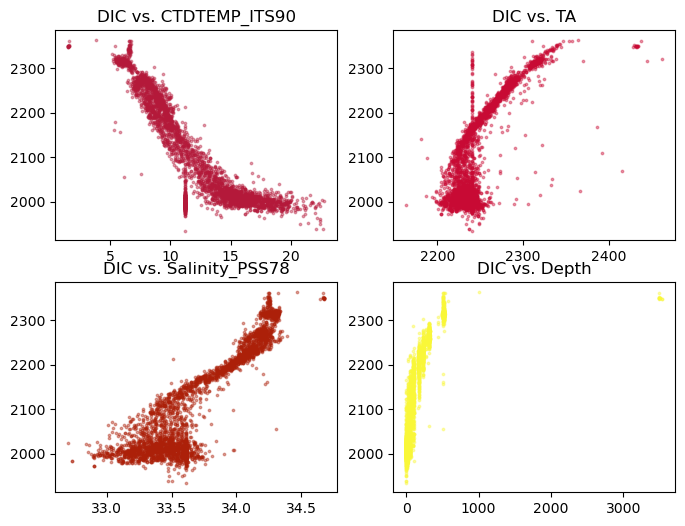

In [5]:
# Plot relationships of predictors & response
fig, axes = plt.subplots(2, 2, figsize = (8, 6))
axes = axes.flatten()
for ax, feature in zip(axes, features):
    ax.scatter(train[feature], train["DIC"], s = 3, alpha = 0.4, color = np.random.rand(3))
    ax.set_title(f"DIC vs. {feature}")

Based on this preliminary visualization, it seems that most predictors have some relationship with DIC, though possibly not ones that can be summarized by linear models. Let's try though.

In [6]:
# Prepare train data for model fitting
X_train = train[features]
y_train = train["DIC"]

X_test = test[features]

# Apply scalar to X values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Mod 1. OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [7]:
# OLS model
ols = LinearRegression().fit(X_train_scaled, y_train)

# Find training MSE
mse_ols = mean_squared_error(y_train, ols.predict(X_train_scaled))

print(f"Training MSE: {mse_ols}")

# Generate submission on test data
submission["DIC"] = ols.predict(X_test_scaled)

# Overwrite submission with one prediction per row
submission.to_csv("output/submission_ols.csv", index = False)

Training MSE: 1438.785117036232


## Mod 2-5. Polynomial and RBF SVR, Lasso and Ridge Regression

Four models that extend the linear baseline. Ridge and Lasso add regularization to penalize large coefficients (Lasso can also zero features out), while the polynomial and RBF support vector regressors allow curved, nonlinear relationships. Each is tuned with a cross-validated grid search over its key hyperparameters.

In [8]:
# Create grid search matrix
models = {
    "poly": GridSearchCV(
        SVR(kernel = 'poly'),
        {'C': [0.1, 1, 10, 100], 
         'gamma': ['scale', 0.001, 0.01, 0.1, 1], 
         'degree': [2, 3, 4], 'coef0': [0, 1]},
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1),
    "rbf": GridSearchCV(
        SVR(kernel = 'rbf'),
        {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1, 10]},
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1),
    "lasso": GridSearchCV(
        Lasso(),
        {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1),
    "ridge": GridSearchCV(
        Ridge(),
        {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1)}

# Loop through each model, fit and extract the best estimator, and generate predictions for those parameters
for name, grid in models.items():
    grid.fit(X_train_scaled, y_train)
    best = grid.best_estimator_
    
    train_mse = mean_squared_error(y_train, best.predict(X_train_scaled))
    print(f"[{name}] Best params: {grid.best_params_} | Train MSE: {train_mse:.3f}")

    sub = submission.copy()
    sub["DIC"] = best.predict(X_test_scaled)
    sub.to_csv(f"output/submission_{name}.csv", index = False)

[poly] Best params: {'C': 1, 'coef0': 1, 'degree': 4, 'gamma': 0.1} | Train MSE: 951.798
[rbf] Best params: {'C': 100, 'gamma': 1} | Train MSE: 329.811
[lasso] Best params: {'alpha': 1} | Train MSE: 1440.002
[ridge] Best params: {'alpha': 10} | Train MSE: 1438.846


# Mod 6. XGB and LGBM models

Two gradient-boosted tree models, each tuned with a cross-validated grid search over its key hyperparameters (number of trees, tree size, learning rate, and regularization). We use shuffled 5-fold CV, which is important here because the data is ordered by depth and station, and select the configuration with the lowest cross-validated MSE. The best version of each becomes a base learner for the stack.

In [9]:
# Keep feature names on scaled data to silences LightGBM warnings
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns = features)

# Shuffle matters! Data is ordered by depth
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

# Create grid search matrix
models = {
    "xgb": GridSearchCV(
        XGBRegressor(random_state = 42, n_jobs = -1),
        {'n_estimators': [100, 300, 500], 'max_depth': [3, 5, 7], 
         'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0], 
         'reg_lambda': [1, 10]},
        cv = kf, scoring = 'neg_mean_squared_error', n_jobs = -1),
    "lgbm": GridSearchCV(
        LGBMRegressor(random_state = 42),
        {'n_estimators': [300, 500], 'num_leaves': [31, 63],
         'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0], 
         'min_child_samples': [10, 30]},
        cv = kf, scoring = 'neg_mean_squared_error', n_jobs = -1)}

# Store the best fitted model and save its test predictions
best_models = {}
for name, grid in models.items():
    grid.fit(X_train_scaled, y_train)
    best_models[name] = grid.best_estimator_
    print(f"[{name}] CV MSE: {-grid.best_score_:.3f} | {grid.best_params_}")

    sub = submission.copy()
    sub["DIC"] = grid.best_estimator_.predict(X_test_scaled)
    sub.to_csv(f"output/submission_{name}.csv", index = False)

# Name estimators for Mod 7
best_xgb  = best_models["xgb"]
best_lgbm = best_models["lgbm"]

[xgb] CV MSE: 194.089 | {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'reg_lambda': 10, 'subsample': 1.0}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 887
[LightGBM] [Info] Number of data points in the train set: 3389, number of used features: 4
[LightGBM] [Info] Start training from score 2117.764681
[lgbm] CV MSE: 197.539 | {'learning_rate': 0.05, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.8}


# Mod 7. Stacked XGB and LGBM models

A stacking ensemble that combines the two tuned tree models. Their cross-validated predictions are passed to a Ridge meta-learner, which learns how to blend them into a single estimate. Because XGB and LGBM make slightly different errors, combining them produces a lower CV MSE than either model alone, which is why we use the stack for the final submission.

In [10]:
# Stacking
stack = StackingRegressor(
    estimators = [('xgb', best_xgb), ('lgbm', best_lgbm)],
    final_estimator = Ridge(), cv = kf, n_jobs = -1)

# Performance estimate
stack_cv = -cross_val_score(stack, X_train_scaled, y_train, cv = kf,
                            scoring = 'neg_mean_squared_error').mean()
print(f"[stack] CV MSE: {stack_cv:.3f}")

# Fit on all training data and write the final submission
stack.fit(X_train_scaled, y_train)
sub = submission.copy()
sub["DIC"] = stack.predict(X_test_scaled)
sub.to_csv("output/submission_stack.csv", index = False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 865
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 866
[LightGBM] [Info] Number of data points in the train set: 2168, number of used features: 4
[LightGBM] [Info] Number of data points in the train set: 2169, number of used features: 4
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Start training from score 2117.783719
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000685 seconds.
You can s